<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/Resume_Screening(Gradient_Boosting).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
path="/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv"
df=pd.read_csv(path)
df.head(5)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.shape

(1000, 11)

In [7]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [8]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [9]:
df.isnull().any().any()

np.True_

In [10]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [11]:
df['Certifications'].fillna('No Certification', inplace=True)
df['Certifications'].isnull().sum()

/tmp/ipykernel_3875/67032770.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Certifications'].fillna('No Certification', inplace=True)


np.int64(0)

In [12]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [13]:
#print missing value
df[df.isnull().any(axis=1)]

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)


In [14]:
print(df['Job Role'].unique())

['AI Researcher' 'Data Scientist' 'Cybersecurity Analyst'
 'Software Engineer']


In [15]:
print(df['Education'].unique())

['B.Sc' 'MBA' 'B.Tech' 'PhD' 'M.Tech']


In [16]:
df['Recruiter_Decision_Mapped'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
display(df.head())

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Recruiter_Decision_Mapped
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100,1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,1
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100,1


In [17]:
df['Recruiter_Decision_Mapped'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
display(df.head())

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Recruiter_Decision_Mapped
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100,1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,1
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100,1


In [18]:
X=df.iloc[:,:-1]
print(X)

     Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...                 ...   
995              Cybe

In [19]:
Y=df.iloc[:,-1]
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    1
998    1
999    1
Name: Recruiter_Decision_Mapped, Length: 1000, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.7,test_size=0.3,random_state=42)

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns for preprocessing
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
categorical_cols = ['Education', 'Certifications', 'Job Role']

# Define columns to drop
drop_cols = ['Resume_ID', 'Name', 'Skills', 'Recruiter Decision']

# Create a preprocessor to handle one-hot encoding for categorical features
# and pass through numerical features. Also, drop specified columns.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('drop_cols', 'drop', drop_cols)
    ],
    remainder='drop' # Drop any other columns not specified
)

# Apply the preprocessor to X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of X_test_processed:", X_test_processed.shape)

Shape of X_train_processed: (700, 17)
Shape of X_test_processed: (300, 17)


In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gradient Boosting Classifier model
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gbc_model.fit(X_train_processed, Y_train)

# Make predictions on the test set
Y_pred = gbc_model.predict(X_test_processed)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00       236

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



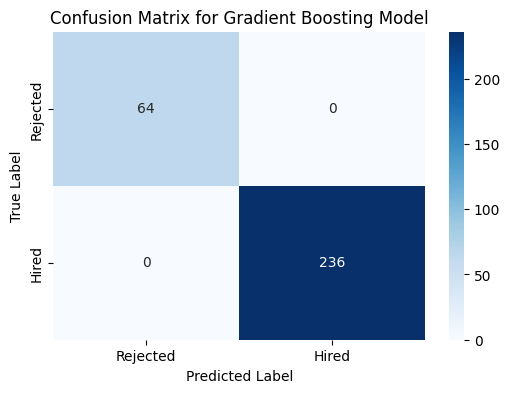

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix for Gradient Boosting Model
cm_gbc = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Hired'], yticklabels=['Rejected', 'Hired'])
plt.title('Confusion Matrix for Gradient Boosting Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.8,test_size=0.2,random_state=42)

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns for preprocessing
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
categorical_cols = ['Education', 'Certifications', 'Job Role']

# Define columns to drop
drop_cols = ['Resume_ID', 'Name', 'Skills', 'Recruiter Decision']

# Create a preprocessor to handle one-hot encoding for categorical features
# and pass through numerical features. Also, drop specified columns.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('drop_cols', 'drop', drop_cols)
    ],
    remainder='drop' # Drop any other columns not specified
)

# Apply the preprocessor to X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of X_test_processed:", X_test_processed.shape)

Shape of X_train_processed: (800, 17)
Shape of X_test_processed: (200, 17)


In [26]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gradient Boosting Classifier model
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gbc_model.fit(X_train_processed, Y_train)

# Make predictions on the test set
Y_pred = gbc_model.predict(X_test_processed)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00       154

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



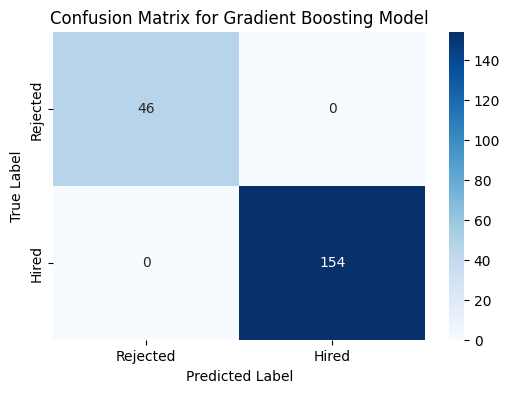

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix for Gradient Boosting Model
cm_gbc = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Hired'], yticklabels=['Rejected', 'Hired'])
plt.title('Confusion Matrix for Gradient Boosting Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

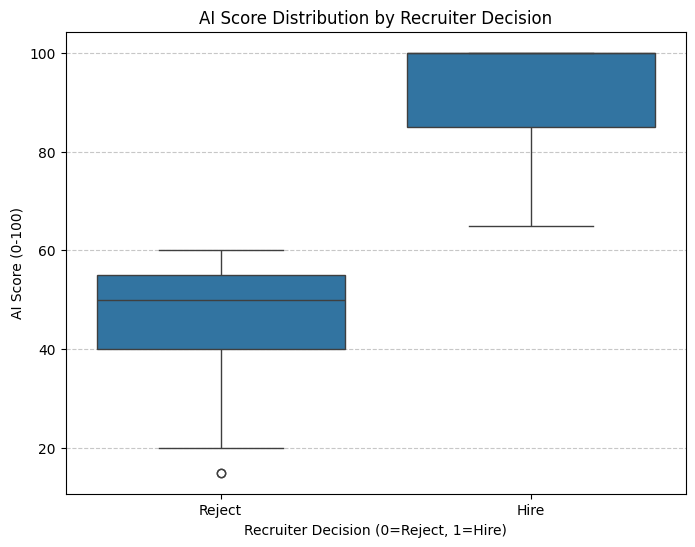

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Recruiter_Decision_Mapped', y='AI Score (0-100)', data=df)
plt.title('AI Score Distribution by Recruiter Decision')
plt.xlabel('Recruiter Decision (0=Reject, 1=Hire)')
plt.ylabel('AI Score (0-100)')
plt.xticks(ticks=[0, 1], labels=['Reject', 'Hire'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()